In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import itertools

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

In [2]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

In [3]:
from true_graph import TrueGraph
from learner import FactorGraphLearner
from noise_generator import IndependentMarginals
from metrics import *
from random_graph import generate_random_graph, generate_random_tree
from chow_liu import chow_liu

# Graphs and Samples

In [4]:
rng = np.random.default_rng(seed=311)
random_graph = generate_random_graph(n=10, alphabet_size=2, n_factors=8, rng=rng)

rng = np.random.default_rng(seed=24)
random_tree = generate_random_tree(n=10, alphabet_size=2, rng=rng)

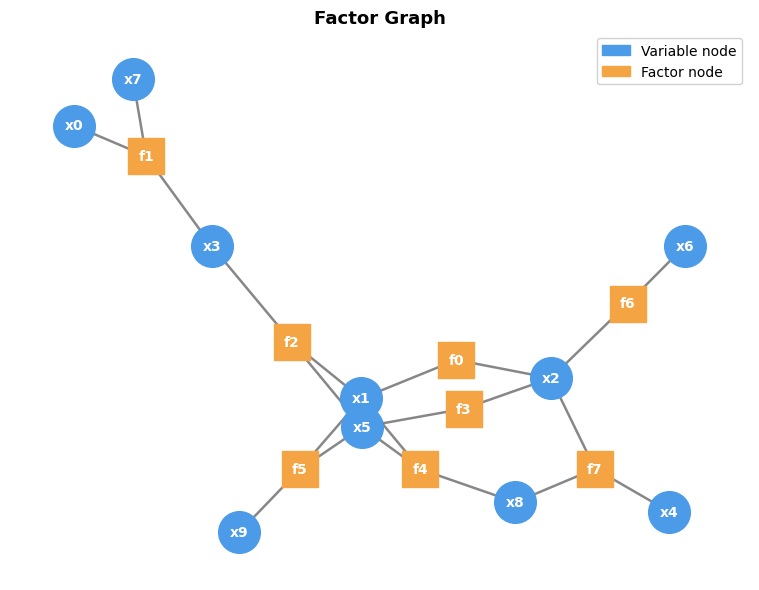

In [5]:
random_graph.display_graph(seed=388)
plt.show()

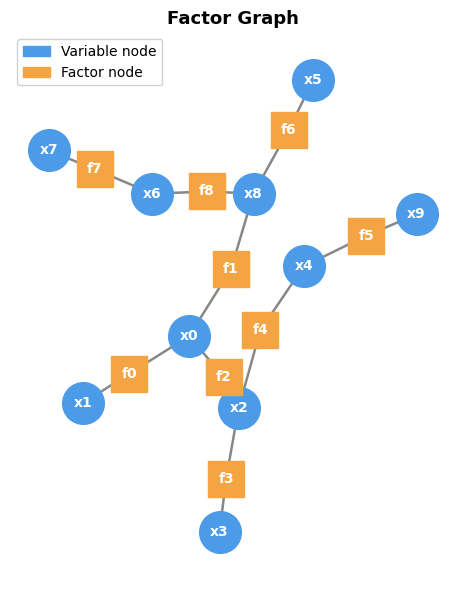

In [6]:
random_tree.display_graph(seed=72)
plt.show()

In [7]:
samples_graph = random_graph.sample(nsamples=500, seed=689)
samples_tree = random_tree.sample(nsamples=500, seed=920)

100%|████████████████████████████████████████| 500/500 [00:01<00:00, 392.71it/s]


# Experiment

In [8]:
def one_learner(graph, samples, K, hidden_dims=(16,16), max_factor_size=None,
                shared_mlp=False, epochs=100, lr=0.01,
                l_mask=0.1, l_weight=0.01, l_mlp=0.01, l_bp=0.001,
                schedule=True, seed=123, verbose=True):

    alph_size = graph.alphabet_sizes[0]
    n_vars = graph.n

    ng = IndependentMarginals(samples, alphabet_size=alph_size, alpha=1, seed=456)

    learner = FactorGraphLearner(
        n_vars=n_vars,
        alphabet_size=alph_size,
        K=K,
        noise_generator=ng,
        hidden_dims=hidden_dims,
        max_factor_size=max_factor_size,
        shared_mlp=shared_mlp,
        seed=seed
    )

    losses, diagnostics = learner.train(
        samples,
        n_epochs=epochs,
        lr=lr,
        lambda_mask=l_mask,
        lambda_weight=l_weight,
        lambda_mlp_l2=l_mlp,
        lambda_bp=l_bp,
        penalty_schedule=schedule,
        verbose=verbose
    )

    return learner, losses, diagnostics

In [9]:
def run_experiment(graph, samples, lambda_bp_vals, K,
                   hidden_dims=(16,16), max_factor_size=None,
                   shared_mlp=False, epochs=100, lr=0.01,
                   l_mask=0.0, l_weight=0.0, l_mlp=0.01,
                   schedule=True, seed=123, verbose=False):

    results = []

    for l_bp in tqdm(lambda_bp_vals):
        learner, losses, dgs = one_learner(
            graph, samples, K,
            hidden_dims=hidden_dims,
            max_factor_size=max_factor_size,
            shared_mlp=shared_mlp,
            epochs=epochs,
            lr=lr,
            l_mask=l_mask,
            l_weight=l_weight,
            l_mlp=l_mlp,
            l_bp=l_bp,
            schedule=schedule,
            seed=seed,
            verbose=verbose
        )

        results.append({
            "lambda_bp": l_bp,
            "nce_loss": losses["Main"][-1],
            "reg_loss": losses["Reg"][-1],
            "total_loss": losses["Total"][-1],
            "n_active_factors": dgs["n_active_factors"][-1],
            "avg_factor_size": dgs["avg_factor_size"][-1],
            "SHD": structural_hamming_distance(graph, learner),
            "KL": kl_divergence(graph, learner),
            "learner": learner  # optional, keep if needed
        })

    return results

In [10]:
lambda_bp_vals = 10 ** np.arange(-4, 0.01, 0.05)

results_graph = run_experiment(
    random_graph, samples_graph, lambda_bp_vals,
    K=15, max_factor_size=5, seed=317
)

results_tree = run_experiment(
    random_tree, samples_tree, lambda_bp_vals,
    K=15, max_factor_size=5, seed=317
)

100%|███████████████████████████████████████████| 81/81 [05:32<00:00,  4.10s/it]


In [11]:
def plot_results(results, x, y):
    x_vec = np.array([r[x] for r in results])
    y_vec = np.array([r[y] for r in results])

    plt.scatter(x_vec, y_vec, alpha=0.7)
    plt.xscale("log")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

In [12]:
def plot_results_binned(results, x, y, nbins=10):
    x_vec = np.array([r[x] for r in results])
    y_vec = np.array([r[y] for r in results])

    idx = np.argsort(x_vec)
    x_sorted = x_vec[idx]
    y_sorted = y_vec[idx]

    n = len(results)

    mean_x, avg, sd = [], [], []

    for i in range(nbins):
        lo = int(n * i / nbins)
        hi = int(n * (i + 1) / nbins)

        x_bin = x_sorted[lo:hi]
        y_bin = y_sorted[lo:hi]

        mean_x.append(np.mean(x_bin))
        avg.append(np.mean(y_bin))
        sd.append(np.std(y_bin))

    plt.plot(mean_x, avg, marker="o")
    plt.xscale("log")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

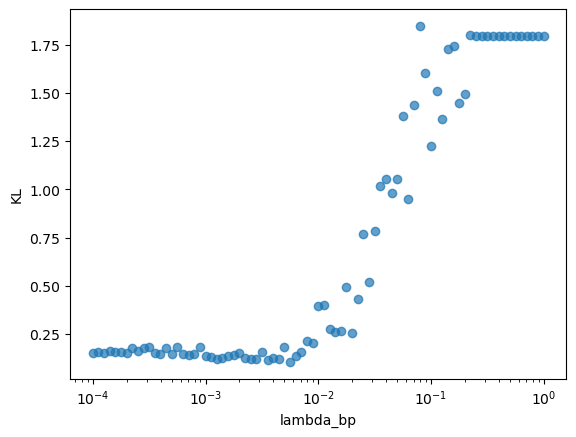

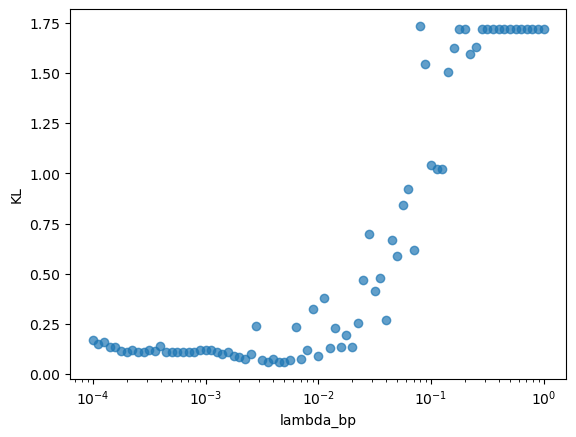

In [13]:
plot_results(results_graph, 'lambda_bp', 'KL')
plot_results(results_tree, 'lambda_bp', 'KL')

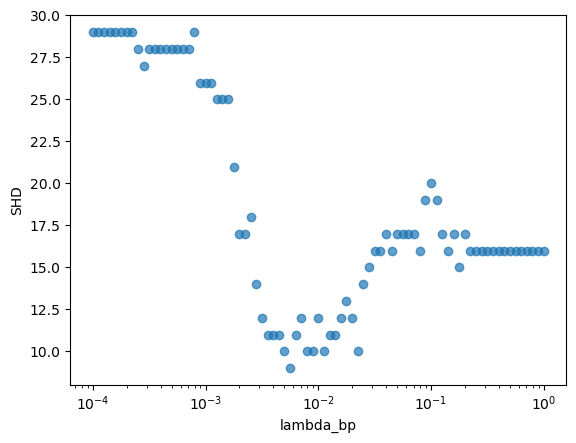

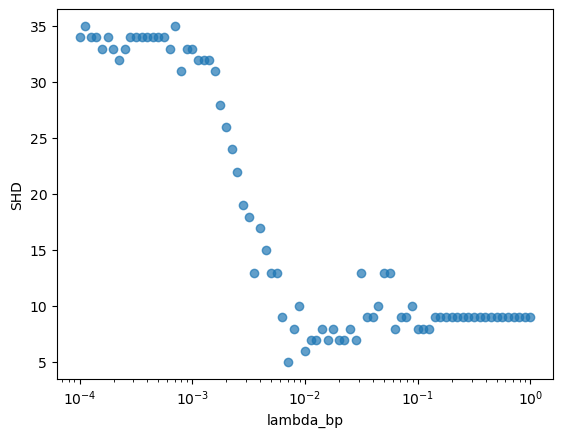

In [14]:
plot_results(results_graph, 'lambda_bp', 'SHD')
plot_results(results_tree, 'lambda_bp', 'SHD')

In [15]:
# def one_learner(n_vars, alphabet_size, samples, K, hidden_dims=(16,16), max_factor_size=None, shared_mlp=False,
#                 epochs=100, lr=0.01, l_mask=0.1, l_weight=0.01, l_mlp=0.01, l_bp=0.001, schedule=True,
#                 seed=123, verbose=True):
#     ng = IndependentMarginals(samples, alphabet_size=alphabet_size, alpha=1, seed=456)
#     lrn = FactorGraphLearner(n_vars=n_vars, alphabet_size=alphabet_size, K=K, noise_generator=ng,
#                              hidden_dims=hidden_dims, max_factor_size=max_factor_size, shared_mlp=shared_mlp, seed=seed)
#     loss, diagnostics = lrn.train(samples, n_epochs=epochs, lr=lr, lambda_mask=l_mask, lambda_weight=l_weight, 
#                                   lambda_mlp_l2=l_mlp, lambda_bp=l_bp, penalty_schedule=schedule, verbose=verbose)
#     return lrn, loss, diagnostics

In [16]:
# def all_learners(graph, samples, reg_strengths, K, hidden_dims=(16,16), max_factor_size=None, shared_mlp=False,
#                  epochs=100, lr=0.01, l_mlp=0.01, schedule=True, verbose=True, seed=123):
#     results = []
#     alph_size = graph.alphabet_sizes[0]
#     n_vars = graph.n
#     for i, (l_mask, l_weight, l_bp) in tqdm(enumerate(reg_strengths), total=len(reg_strengths)):
#         ng = IndependentMarginals(samples, alphabet_size=alph_size, alpha=1, seed=456)
#         lrn, ls, dgs = one_learner(n_vars, alph_size, samples, K, hidden_dims, max_factor_size, shared_mlp, epochs, lr, l_mask,
#                                    l_weight, l_mlp, l_bp, schedule, seed, verbose)
        
#         results.append({
#             'lambda_mask' : l_mask,
#             'lambda_weight' : l_weight,
#             'lambda_bp' : l_bp,
#             'lrn' : lrn,
#             'nce_loss': ls['Main'][-1],
#             'reg_loss' : ls['Reg'][-1],
#             'total_loss': ls['Total'][-1],
#             'n_active_factors' : dgs['n_active_factors'][-1],
#             'avg_factor_size' : dgs['avg_factor_size'][-1],
#             'SHD' : structural_hamming_distance(graph, lrn),
#             'KL' : kl_divergence(graph, lrn)
#         })
#         # print(f"Completed {i+1}/{len(reg_strengths)}")
#     return results

In [17]:
# randomly generate regs
# n_runs = 100
# rng = np.random.default_rng(seed=226)
# regs = 10**rng.uniform(-4,0,size=(n_runs,3))
# regs = [tuple(regs[i,:]) for i in range(regs.shape[0])]

# regs_bp = 10**np.arange(-4,0.1,0.1)
# regs = np.hstack([0.01 * np.ones((len(regs_bp),2)), regs_bp.reshape(-1,1)])

# results_graph = all_learners(random_graph, samples_graph, regs, K=15, max_factor_size=5, verbose=False, seed=317)

In [18]:
# results_tree = all_learners(random_tree, samples_tree, regs, K=15, max_factor_size=5, verbose=False, seed=317)

In [19]:
# import pickle

# path = "../experiments/reg_graph_grid.pkl"
# with open(path, "wb") as f:
#     pickle.dump(results_graph, f)

# path = "../experiments/reg_tree_grid.pkl"
# with open(path, "wb") as f:
#     pickle.dump(results_tree, f)

In [20]:
# import pickle

# path = "../experiments/reg.pkl"
# with open(path, "rb") as f:
#     results_graph = pickle.load(f)

In [21]:
# import matplotlib.pyplot as plt

# def plot_results(results, x, y):
#     x_vec = [r[x] for r in results]
#     y_vec = [r[y] for r in results]

#     plt.scatter(x_vec, y_vec)
#     plt.xscale('log')
#     plt.xlabel(x)
#     plt.ylabel(y)
#     plt.show()

# plot_results(results_tree, 'lambda_bp', 'KL')

In [22]:
# results_graph

In [23]:
# def plot_results_binned(results, x, y, nbins=10):
#     n_res = len(results)
#     x_vec = np.array([r[x] for r in results])
#     y_vec = np.array([r[y] for r in results])
#     x_idx = np.argsort(x_vec)
#     x_sorted = x_vec[x_idx]
#     y_sorted = y_vec[x_idx]

#     mean_x = np.zeros(n_bins)
#     avg = np.zeros(n_bins)
#     sd =  np.zeros(n_bins)

#     for i in range(n_bins):
#         lower = int(n_res * i/n_bins)
#         upper = int(n_res * (i+1)/n_bins)
#         x_here = x_sorted[lower:upper]
#         y_here = y_sorted[lower:upper]
#         mean_x[i] = np.mean(x_here)
#         avg[i] = np.mean(y_here)
#         sd[i] = np.std(y_here)

#     plt.plot(mean_x, avg)
#     plt.xscale('log')
#     plt.xlabel(x)
#     plt.ylabel(y)
#     plt.show()

# plot_results_binned(results_tree, "lambda_bp", "SHD", 5)

# Recovered Graphs

In [26]:
best_lrn_graph, ls_graph, dg_graph = one_learner(random_graph, samples_graph, K=15, max_factor_size=5, 
                                                 l_mask=0.0, l_weight=0.0, l_bp=0.005, seed=317)
best_lrn_tree, ls_tree, gd_tree = one_learner(random_tree, samples_tree, K=15, max_factor_size=5,
                                              l_mask=0.0, l_weight=0.0, l_bp=0.005, seed=317)

Epoch   50/100  loss=0.5911  main=0.5547  reg=0.0364
Epoch  100/100  loss=0.5363  main=0.5231  reg=0.0132
Epoch   50/100  loss=0.6465  main=0.6107  reg=0.0358
Epoch  100/100  loss=0.6277  main=0.6145  reg=0.0131


In [27]:
best_res_graph = {
    'n_active_factors' : best_lrn_graph.network.n_active_factors().item(),
    'avg_factor_size' : best_lrn_graph.network.avg_factor_size().item(),
    'SHD' : structural_hamming_distance(random_graph, best_lrn_graph),
    'KL' : kl_divergence(random_graph, best_lrn_graph)
}

best_res_tree = {
    'n_active_factors' : best_lrn_tree.network.n_active_factors().item(),
    'avg_factor_size' : best_lrn_tree.network.avg_factor_size().item(),
    'SHD' : structural_hamming_distance(random_tree, best_lrn_tree),
    'KL' : kl_divergence(random_tree, best_lrn_tree)
}

In [28]:
compare_graph(random_graph, best_lrn_graph)

=== GRAPH 1 FACTORS ===
[1, 2]
[0, 3, 7]
[1, 3, 5]
[2, 5]
[1, 5, 8]
[1, 5, 9]
[2, 6]
[2, 4, 8]

=== GRAPH 2 FACTORS ===
[1, 3, 5, 9]
[0, 7]
[0, 1]
[1, 5]
[1, 2]
[2, 5, 9]
[3, 5]
[2, 4, 8]
[7]
[6, 8]


In [29]:
compare_graph(random_tree, best_lrn_tree)

=== GRAPH 1 FACTORS ===
[0, 1]
[0, 8]
[0, 2]
[2, 3]
[2, 4]
[4, 9]
[5, 8]
[6, 7]
[6, 8]

=== GRAPH 2 FACTORS ===
[0, 2, 3, 8]
[6, 7]
[0, 6, 8]
[0]
[5, 7, 8]
[2, 3, 4, 9]
[3, 7]
[0, 1]
[5, 8]


In [30]:
kl_mle_optimal(random_graph, samples_graph)

0.37322691928488594

In [31]:
chow_liu_graph = chow_liu(samples_graph, alphabet_size=2)
chow_liu_res_graph = {
    'n_active_factors' : len(chow_liu_graph.factors),
    'avg_factor_size' : np.mean([len(sc) for sc, f in chow_liu_graph.factors]),
    'SHD' : structural_hamming_distance(random_graph, chow_liu_graph),
    'KL' : kl_divergence(random_graph, chow_liu_graph)
}

chow_liu_tree = chow_liu(samples_tree, alphabet_size=2)
chow_liu_res_tree = {
    'n_active_factors' : len(chow_liu_tree.factors),
    'avg_factor_size' : np.mean([len(sc) for sc, f in chow_liu_tree.factors]),
    'SHD' : structural_hamming_distance(random_tree, chow_liu_tree),
    'KL' : kl_divergence(random_tree, chow_liu_tree)
}

In [32]:
chow_liu_res_graph, best_res_graph

({'n_active_factors': 10,
  'avg_factor_size': 1.9,
  'SHD': 9,
  'KL': 0.13101763802609706},
 {'n_active_factors': 8,
  'avg_factor_size': 2.375,
  'SHD': 9,
  'KL': 0.13083311018365176})

In [33]:
chow_liu_res_tree, best_res_tree

({'n_active_factors': 10,
  'avg_factor_size': 1.9,
  'SHD': 0,
  'KL': 0.012789733215894338},
 {'n_active_factors': 7,
  'avg_factor_size': 2.7142856121063232,
  'SHD': 10,
  'KL': 0.05427753081135671})

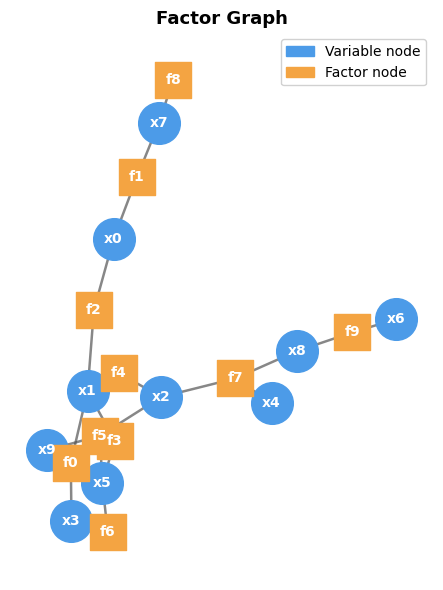

In [34]:
def vis_learned_graph(lrn, seed=1):
    fscopes = lrn.extract_graph()['factor_scopes']
    def h(): return 1
    factors = [(f, h) for f in fscopes.values()]
    g = TrueGraph(n=lrn.network.n_vars, factors=factors)
    g.display_graph(seed=seed)

vis_learned_graph(best_lrn_graph, 34)

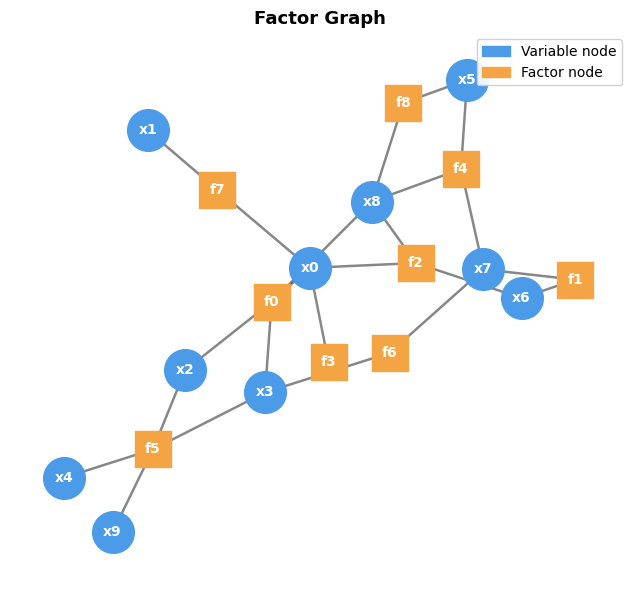

In [35]:
vis_learned_graph(best_lrn_tree, 34)

In [36]:
kl_mle_optimal(random_tree, samples_tree)

0.40577652351832594

# Final Visualizations

1) KL and SHD vs lambda_bp for loopy graph and tree
   - KL graph on left, SHD on right [or maybe 4 separate graphs - would make stuff with dotted lines simpler]
   - color by graph type (loopy vs tree)
   - Have dotted lines for MLE and Chow-Liu KL on KL graph, dotted lines for Chow-Liu SHD on SHD graph
2) Show graphs
   - True graph, recovered graph (optimal), and recovered graph (too much or too little or both)